In [1]:
import time
import h5py

import numpy as np
import matplotlib.pyplot as plt

import sys
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
%matplotlib widget 

In [2]:
base_folder =  '/sdf/data/lcls/ds/rix/'
#run = 104 #XAS step mono
#run = 119 #waveplate
#run = 151 #fixed energy
#run = 76 #XAS fly mono

bgrun = 3
run = 47

#exp = 'rix100836924'
exp = 'rix101265125'
#79,81,82,83,85,94,95,96,98



#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
#bgname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{bg:04d}.h5'
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'
# with h5py.File(fname, 'r') as fh:
#     data = SmallData(fh,fyaml)
#     with h5py.File(bgname, 'r') as fhbg:
#         red =Reduced(fh,fhbg,fyaml,clear_memory=False)

#with SmallData(fname,fyaml) as data:
# with Reduced(fname,bgname,fyaml) as red:
#     red.data.integrating.axis_svls.full_area

#red = Reduced(fname,bgname,fyaml,scantype='mono_fly')
data = SmallData(fname,fyaml)
bg = SmallData(bgname, bgyaml)

In [4]:
red = Reduced(fname,bgname,fyaml,bgyaml, save=True,scantype='mono_fly')


accessing intgrp
accessing epics
initialising <HDF5 group "/intg/andor_vls" (63 members)>
setting up properties
initialising <HDF5 group "/intg/axis_svls" (64 members)>
setting up properties
apds does not exits 
apds does not exits 
accessing scan variable
accessing intgrp
accessing epics
initialising <HDF5 group "/intg/andor_vls" (94 members)>
setting up properties
initialising <HDF5 group "/intg/axis_svls" (97 members)>
setting up properties
accessing scan variable
<KeysViewHDF5 ['Sums', 'epics_archiver', 'intg', 'timestamp', 'timing']>
scantype is mono_fly
fly scan!
(91,)
(91,)
andor_vls_on_sum
fly scan!
(91,)
(91,)
axis_svls_on_sum
andor_vls_on_sum
andor_vls_off_sum
andor_vls_on_mean
andor_vls_off_mean
andor_vls_on_std
andor_vls_off_std
scanvar_on
scanvar_off
axis_svls_on_sum
axis_svls_off_sum
axis_svls_on_mean
axis_svls_off_mean
axis_svls_on_std
axis_svls_off_std
saved processed data


accessing intgrp
accessing epics
initialising <HDF5 group "/intg/andor_vls" (94 members)>
setting up properties
initialising <HDF5 group "/intg/axis_svls" (97 members)>
setting up properties
accessing scan variable
scanvariable unknown


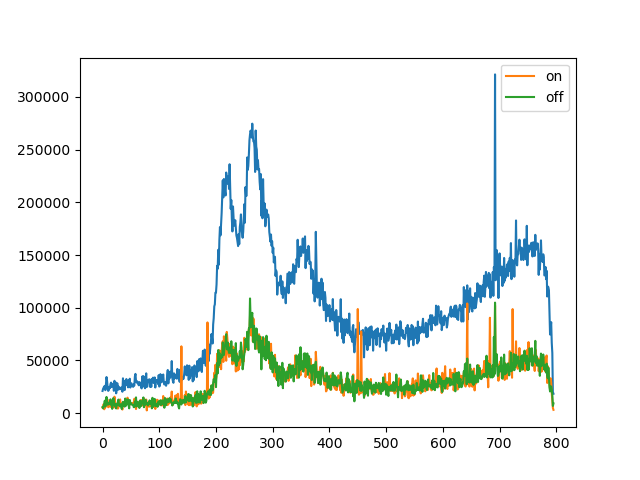

In [6]:
fig,ax=plt.subplots(1,1)

ax.plot(np.nansum(data.integrating.axis_svls.full_area,axis=0))
ax.plot(np.sum(red.axis_svls_on_mean,axis=0)*5e8,label='on')
ax.plot(np.sum(red.axis_svls_off_mean,axis=0)*5e8,label='off')
ax.legend()

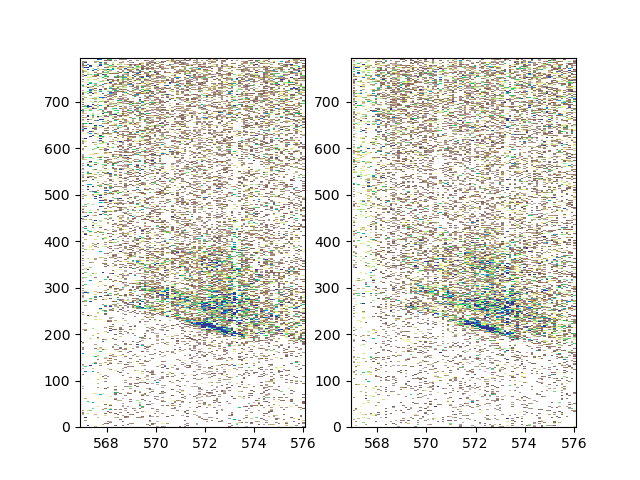

In [7]:

fig,ax=plt.subplots(1,2)
ax[0].pcolor(red.scanvar_on,np.arange(red.axis_svls_on_mean.shape[1]),red.axis_svls_on_mean.T,cmap='terrain_r',vmin=-0,vmax=np.max(red.axis_svls_off_mean)/10)
ax[1].pcolor(red.scanvar_off,np.arange(red.axis_svls_off_mean.shape[1]),red.axis_svls_off_mean.T,cmap='terrain_r',vmin=0,vmax=np.max(red.axis_svls_off_mean)/10)

(array([6690.,    0.,    0.,    0., 1175., 6676.,    0.,    0.,    0.,
          53.]),
 array([767.50770187, 767.6825416 , 767.85738132, 768.03222104,
        768.20706076, 768.38190049, 768.55674021, 768.73157993,
        768.90641965, 769.08125938, 769.2560991 ]),
 <BarContainer object of 10 artists>)

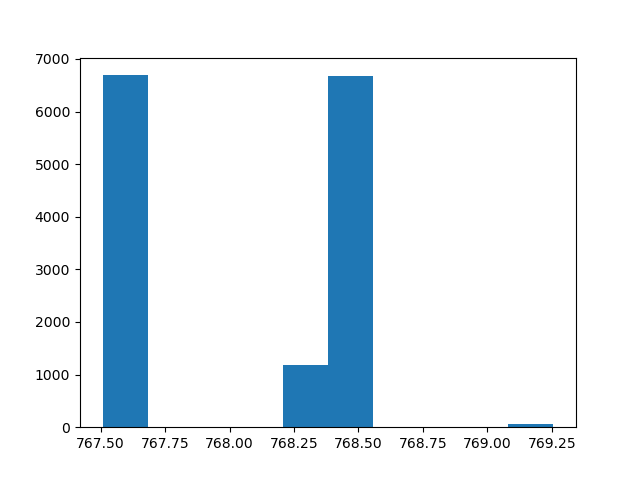

In [12]:
fig,ax=plt.subplots(1,1)
ax.hist(red.data.integrating.andor_vls.mono[onmask])

In [6]:
red.data.integrating.andor_vls.full_area.shape

(29187, 2048)

In [ ]:
fig,ax=plt.subplots(1,1)
ax.plot(red.andor_vls_off)
ax.plot(red.andor_vls_off)

In [ ]:
cal=[-9.86289253e-04,  1.01299833e+03]
hrencoder = red.data.integrating.andor_vls.mono_encoder

np.polyval(cal,hrencoder)

In [ ]:
sm = SmallData(fname,fyaml)

In [ ]:
dat = h5py.File(fname, 'r')
dat['intg']['axis_svls'].keys()

In [ ]:
data.singleshot.fim_0.full_area
bg_roi=[0,50]
bg = np.mean(data.singleshot.fim_0.full_area[...,bg_roi[0]:bg_roi[1]],axis= -1)
bgf = data.singleshot.fim_0.full_area - bg[...,np.newaxis]

In [ ]:
fim_roi=[60,70]

fim_proc =subtract_bg(data.singleshot.fim_0.full_area,[0,50])
fim_wf_avs = np.nanmean(fim_proc,axis = 0)
# fim = np.sum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = (1,2))

# fim = np.nansum(fim_proc[:,:,fim_roi[0]:fim_roi[1]],axis = (1,2))

fim_sum_all = np.nansum(np.abs(fim_proc[:,:,fim_roi[0]:fim_roi[1]]),axis = 2)

In [2]:
# run=76
# fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
# test = h5py.File(fname, 'r')
#run=142
#fname = f'/sdf/data/lcls/ds/rix/rix100836924/scratch/h5/rix100836924_Run{run:04d}.h5'
run=41
fname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{run:04d}.h5'
test1 = h5py.File(fname, 'r')
test1.keys()


NameError: name 'base_folder' is not defined

In [ ]:
premirror = get_premirror_pitch(red.data.epics['MONO_premirror_pitch'][:])
hrencoder = red.data.integrating.andor_vls.mono_encoder
hr_pitch = hrencoder_to_pitch(hrencoder, red.data.yaml['mono_calib'])
hr_energy = mono_energy(hr_pitch,premirror)
hr_energy

['/epics_archiver/SP1K1_MONO_MMS_M_PI.RBV']


In [25]:
testfile = h5py.File('testsave.h5','w')
keys = vars(red)

for dat in keys:
    if 'on' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])
    elif 'off' in dat:
        print(dat)
        testfile.create_dataset(dat,dtype='f',data=keys[dat])


testfile.close()

andor_vls_on_sum
andor_vls_off_sum
andor_vls_on_mean
andor_vls_off_mean
andor_vls_on_std
andor_vls_off_std
scanvar_on
scanvar_off
axis_svls_on_sum
axis_svls_off_sum
axis_svls_on_mean
axis_svls_off_mean
axis_svls_on_std
axis_svls_off_std


In [26]:
test = h5py.File('testsave.h5')

In [27]:
test.keys()

<KeysViewHDF5 ['andor_vls_off_mean', 'andor_vls_off_std', 'andor_vls_off_sum', 'andor_vls_on_mean', 'andor_vls_on_std', 'andor_vls_on_sum', 'axis_svls_off_mean', 'axis_svls_off_std', 'axis_svls_off_sum', 'axis_svls_on_mean', 'axis_svls_on_std', 'axis_svls_on_sum', 'scanvar_off', 'scanvar_on']>

In [30]:
red.data.runinfo

'mono_fly'